# Dataset Loading: 

In [3]:
%pip install datasets
%pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
#loading the dataset:

from datasets import load_dataset, load_metric
dataset = load_dataset("surrey-nlp/PLOD-CW")

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 1072
    })
    validation: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 126
    })
    test: Dataset({
        features: ['tokens', 'pos_tags', 'ner_tags'],
        num_rows: 153
    })
})

In [7]:
train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

**Plot for abbreviation and long form:**

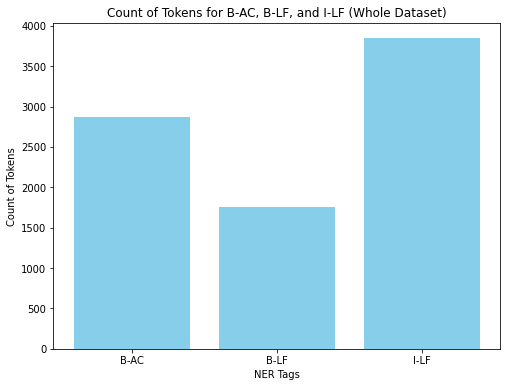

In [9]:
import matplotlib.pyplot as plt
# Combine tokens and NER tags from all datasets
all_tokens = train_dataset['tokens'] + validation_dataset['tokens'] + test_dataset['tokens']
all_ner_tags = train_dataset['ner_tags'] + validation_dataset['ner_tags'] + test_dataset['ner_tags']

# Initialize label counts
label_counts = {'B-AC': 0, 'B-LF': 0, 'I-LF': 0}

# Count tokens for specified NER tags
for ner_tag_list in all_ner_tags:
    for ner_tag in ner_tag_list:
        if ner_tag in label_counts:
            label_counts[ner_tag] += 1

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.title('Count of Tokens for B-AC, B-LF, and I-LF (Whole Dataset)')
plt.xlabel('NER Tags')
plt.ylabel('Count of Tokens')
plt.show()


**Plot for the distribution of pos_tags:**

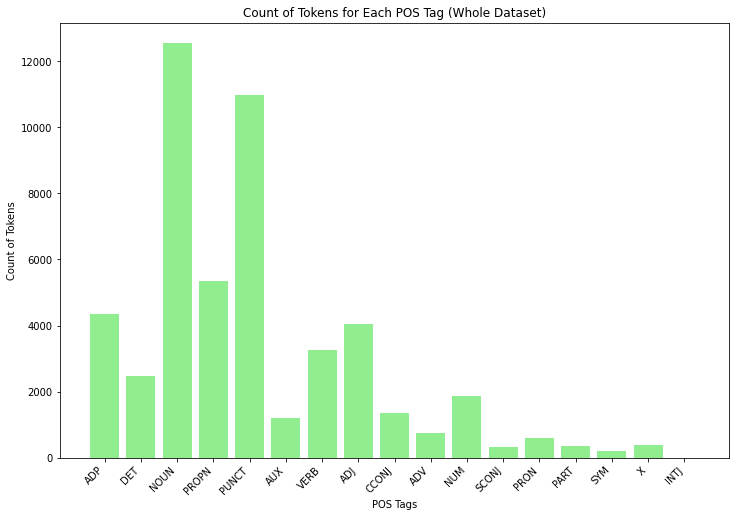

In [10]:
all_pos_tags = train_dataset['pos_tags'] + validation_dataset['pos_tags'] + test_dataset['pos_tags']

pos_counts = {}

for pos_tag_list in all_pos_tags:
    for pos_tag in pos_tag_list:
        if pos_tag in pos_counts:
            pos_counts[pos_tag] += 1
        else:
            pos_counts[pos_tag] = 1


plt.figure(figsize=(12, 8))
plt.bar(pos_counts.keys(), pos_counts.values(), color='lightgreen')
plt.title('Count of Tokens for Each POS Tag (Whole Dataset)')
plt.xlabel('POS Tags')
plt.ylabel('Count of Tokens')
plt.xticks(rotation=45, ha='right')
plt.show()


**Comparision of B-O tags with other tags:**

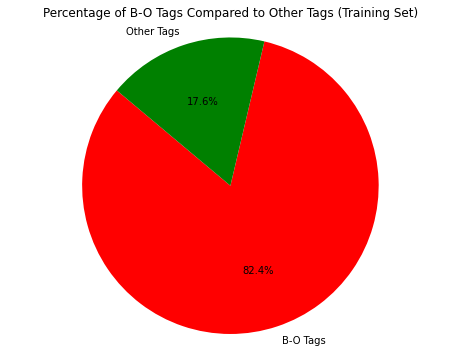

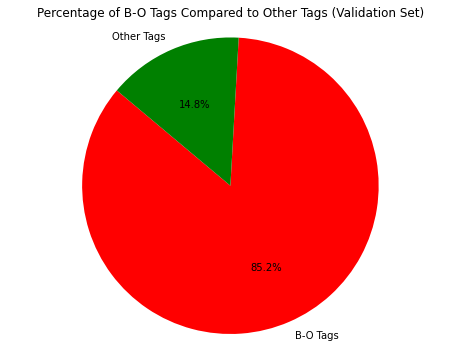

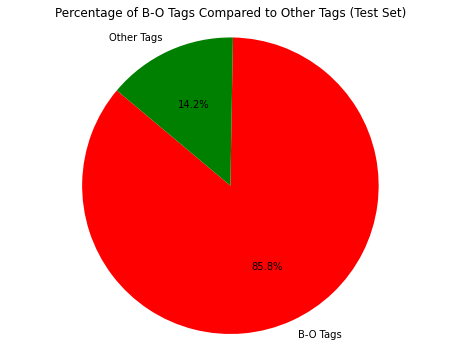

In [15]:
labels = ['B-O Tags', 'Other Tags']
colors = ['red', 'green']

plt.figure(figsize=(8, 6))
plt.pie([train_bo_percentage, train_other_percentage], labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of B-O Tags Compared to Other Tags (Training Set)')
plt.axis('equal')  
plt.show()

# Pie chart for the validation set
plt.figure(figsize=(8, 6))
plt.pie([validation_bo_percentage, validation_other_percentage], labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of B-O Tags Compared to Other Tags (Validation Set)')
plt.axis('equal')  
plt.show()

# Pie chart for the test set
plt.figure(figsize=(8, 6))
plt.pie([test_bo_percentage, test_other_percentage], labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of B-O Tags Compared to Other Tags (Test Set)')
plt.axis('equal')  
plt.show()


**Top 10 most repeated alphabetical words:**

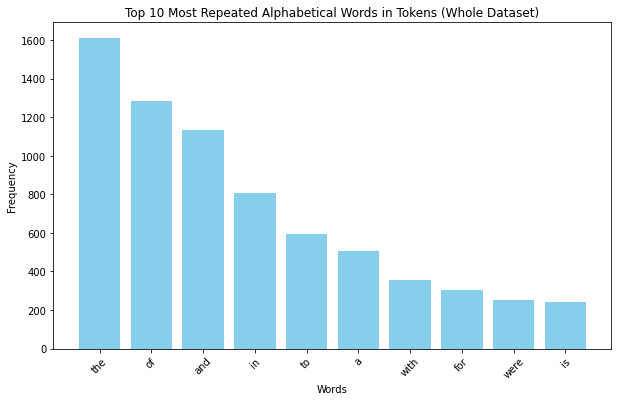

In [18]:
from collections import Counter
import re
all_tokens = train_dataset['tokens'] + validation_dataset['tokens'] + test_dataset['tokens']
all_words = [word.lower() for sublist in all_tokens for word in sublist if re.match('^[a-zA-Z]+$', word)]
word_counts = Counter(all_words)
top_n = 10  
most_common_words = word_counts.most_common(top_n)
words = [word[0] for word in most_common_words]
counts = [count[1] for count in most_common_words]
plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.title(f'Top {top_n} Most Repeated Alphabetical Words in Tokens (Whole Dataset)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()